In [ ]:
%load_ext autoreload
%autoreload 2
%env CUDA_VISIBLE_DEVICES=1

import numpy as np
import sys
import os
import matplotlib.pyplot as plt
import vis_utils

from utils.utils import get_path
from utils.io_utils import load_multiple_res
from utils.toydata_utils import get_toy_data
from utils.fig_utils import dataset_to_print, plot_dgm_loops, dist_to_print
from utils.pd_utils import sort_cycle

from vis_utils.loaders import load_dataset
from vis_utils.plot import plot_scatter
from vis_utils.utils import load_dict, save_dict
from vis_utils.tsne_wrapper import TSNEwrapper
from openTSNE.affinity import Affinities

import umap
from ripser import Rips
from ripser.ripser import get_greedy_perm

from mpl_toolkits.axes_grid1 import make_axes_locatable

from matplotlib import collections  as mc
from matplotlib.colors import Normalize
import matplotlib.cm

from openTSNE.nearest_neighbors import PrecomputedNeighbors
from openTSNE.affinity import PerplexityBasedNN

from vis_utils.utils import kNN_graph, kNN_dists
from scipy.spatial.distance import pdist, squareform
import glasbey
import scipy.sparse
import networkx as nx

from sklearn.decomposition import PCA

from persim import plot_diagrams
from utils.pd_utils import get_life_times
import pandas as pd

from vis_utils.rnaseqTools import geneSelection, sparseload
import pickle
import torch
import urllib.request
import requests
 

env: CUDA_VISIBLE_DEVICES=1
[KeOps] Warning : cuda was detected, but driver API could not be initialized. Switching to cpu only.


# path

In [520]:
root_path = get_path("data")
fig_path = os.path.join(root_path, "figures")
seeds = [0]
k = 15

In [453]:
style_file = "utils.style"
plt.style.use(style_file)

In [454]:
distances = {
    "euclidean": [{}],
    "diffusion": [
        {"k": 15, "t": 8, "kernel": "sknn", "include_self": False},
        {"k": 100, "t": 8, "kernel": "sknn", "include_self": False},
        {"k": 15, "t": 64, "kernel": "sknn", "include_self": False},
        {"k": 100, "t": 64, "kernel": "sknn", "include_self": False},
        # {"k": 100, "t": 128, "kernel": "sknn", "include_self": False},
        # {"k": 200, "t": 64, "kernel": "sknn", "include_self": False},
        # {"k": 200, "t": 128, "kernel": "sknn", "include_self": False},
    ],
    "eff_res": [
        {"corrected": True, "weighted": False, "k": 15, "disconnect": True},
        {"corrected": True, "weighted": False, "k": 100, "disconnect": True},
        # {"corrected": True, "weighted": False, "k": 200, "disconnect": True},
        # {"corrected": True, "weighted": False, "k": 300, "disconnect": True},
    ],
}

In [894]:
n_epochs = 500
n_early_epochs = 250
perplexity = None    
rescale_tsne = True
# seed = 0
file_name = os.path.join(root_path,
                         "yao_10x_female",
                         f"tsne_bin_k_{k}_n_epochs_{n_epochs}_n_early_epochs_{n_early_epochs}_seed_0_init_pca_rescale_{rescale_tsne}.pkl")
tsne_data = load_dict(file_name)
embd = tsne_data["embds"][-1]

In [456]:
def reorder_yaxis(item):
    number, letter = item.split('_')
    return (letter, 300-int(number))

In [457]:
def smooth_curve(nums): # only if isolated...
    if len(nums) < 3:
        return nums
    
    result = [nums[0]]  

    for i in range(1, len(nums) - 1):
        if nums[i] == nums[i - 1] or nums[i] == nums[i + 1]:
            result.append(nums[i])

    result.append(nums[-1])
    
    lens = len(result)

    return result, lens

In [458]:
def compute_density(cell_list, cluster_template):
    lens = len(cell_list)
    density = []
    for cluster in cluster_template:
        count = cell_list.count(cluster)
        density.append(count)
    # print(density)
    density = np.array(density)/lens
    return density

# mask making

In [881]:
_, _, _, _, full_d = load_dataset(root_path, "yao_10x_female", k=k)

In [891]:
full_d["clusters"].shape

(400888,)

In [882]:
idx_orange = [i for i, cluster in enumerate(full_d["clusterNames"]) 
              if "_Sst" in cluster or "_Pvalb" in cluster]
cluster_orange = [cluster for i, cluster in enumerate(full_d["clusterNames"]) 
                  if "_Sst" in cluster or "_Pvalb" in cluster]

In [883]:
mask_orange = [idx in idx_orange for idx in full_d['clusters']]
idx_mask_orange = [i for i, idx in enumerate(full_d['clusters']) if idx in idx_orange ]


In [895]:
len(embd)

400888

# load data

In [876]:
x, y, sknn, pca2, d = load_dataset(root_path, "yao_10x_female_orange", k=15, seed=0)
all_res = load_multiple_res(datasets="yao_10x_female_orange_10k", n=None, embd_dims=None, sigmas=None, distances=distances, seeds=seeds, root_path=root_path, n_threads=1)

Done with yao_10x_female_orange_10k None euclidean n_outliers=0, perturbation=None
Done with yao_10x_female_orange_10k None diffusion_k_15_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_female_orange_10k None diffusion_k_100_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_female_orange_10k None diffusion_k_15_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_female_orange_10k None diffusion_k_100_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_female_orange_10k None eff_res_corrected_True_weighted_False_k_15_disconnect_True n_outliers=0, perturbation=None
Done with yao_10x_female_orange_10k None eff_res_corrected_True_weighted_False_k_100_disconnect_True n_outliers=0, perturbation=None


In [877]:
len(d['clusters'])

25000

# color demo

[]

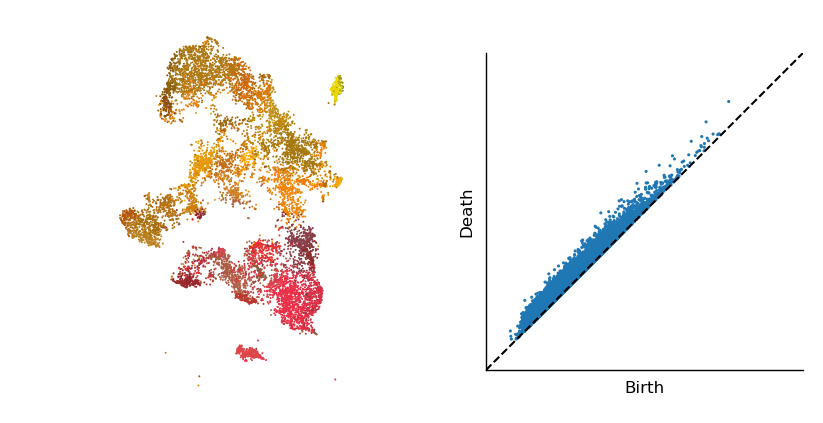

In [ ]:
n_cols = 2
plot_loops = False

width_ratios = [0.75] + [1 ] * (n_cols - 1)

seed = 0
size = 1

distance = "euclidean"
full_dist = "euclidean"

res = all_res[distance][full_dist]
fig, ax = plt.subplots(nrows=1, ncols=n_cols, figsize=(4, 2), constrained_layout=True, width_ratios=width_ratios[::-1])
np.random.seed(0)
mm_o = np.random.choice(len(idx_mask_orange), 10000, replace=False)

plot_dgm_loops(res, embd=embd[mask_orange][mm_o], y=d['clusterColors'][d['clusters']][mm_o], n_loops=0, ax=ax[::-1], plot_only=[1],
               style=style_file, linewidth=1, plot_loops=plot_loops, s=2)
# for s in range(n_cols - 1):
#     ax[s].set_xlim(-90, 0)

ax[1].legend().set_visible(False)
ax[1].set_xticks([])
ax[1].set_yticks([])

# fig.savefig(os.path.join(get_path("figures"), f"yao_smart_orange_dgms_eucl_no_loops.png"), dpi=300)

# 7*7

In [897]:
all_res = load_multiple_res(datasets="yao_10x_female_orange_10k", n=None, embd_dims=None, sigmas=None, distances=distances, seeds=seeds, root_path=root_path, n_threads=1)

Done with yao_10x_female_orange_10k None euclidean n_outliers=0, perturbation=None
Done with yao_10x_female_orange_10k None diffusion_k_15_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_female_orange_10k None diffusion_k_100_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_female_orange_10k None diffusion_k_15_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_female_orange_10k None diffusion_k_100_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_female_orange_10k None eff_res_corrected_True_weighted_False_k_15_disconnect_True n_outliers=0, perturbation=None
Done with yao_10x_female_orange_10k None eff_res_corrected_True_weighted_False_k_100_disconnect_True n_outliers=0, perturbation=None


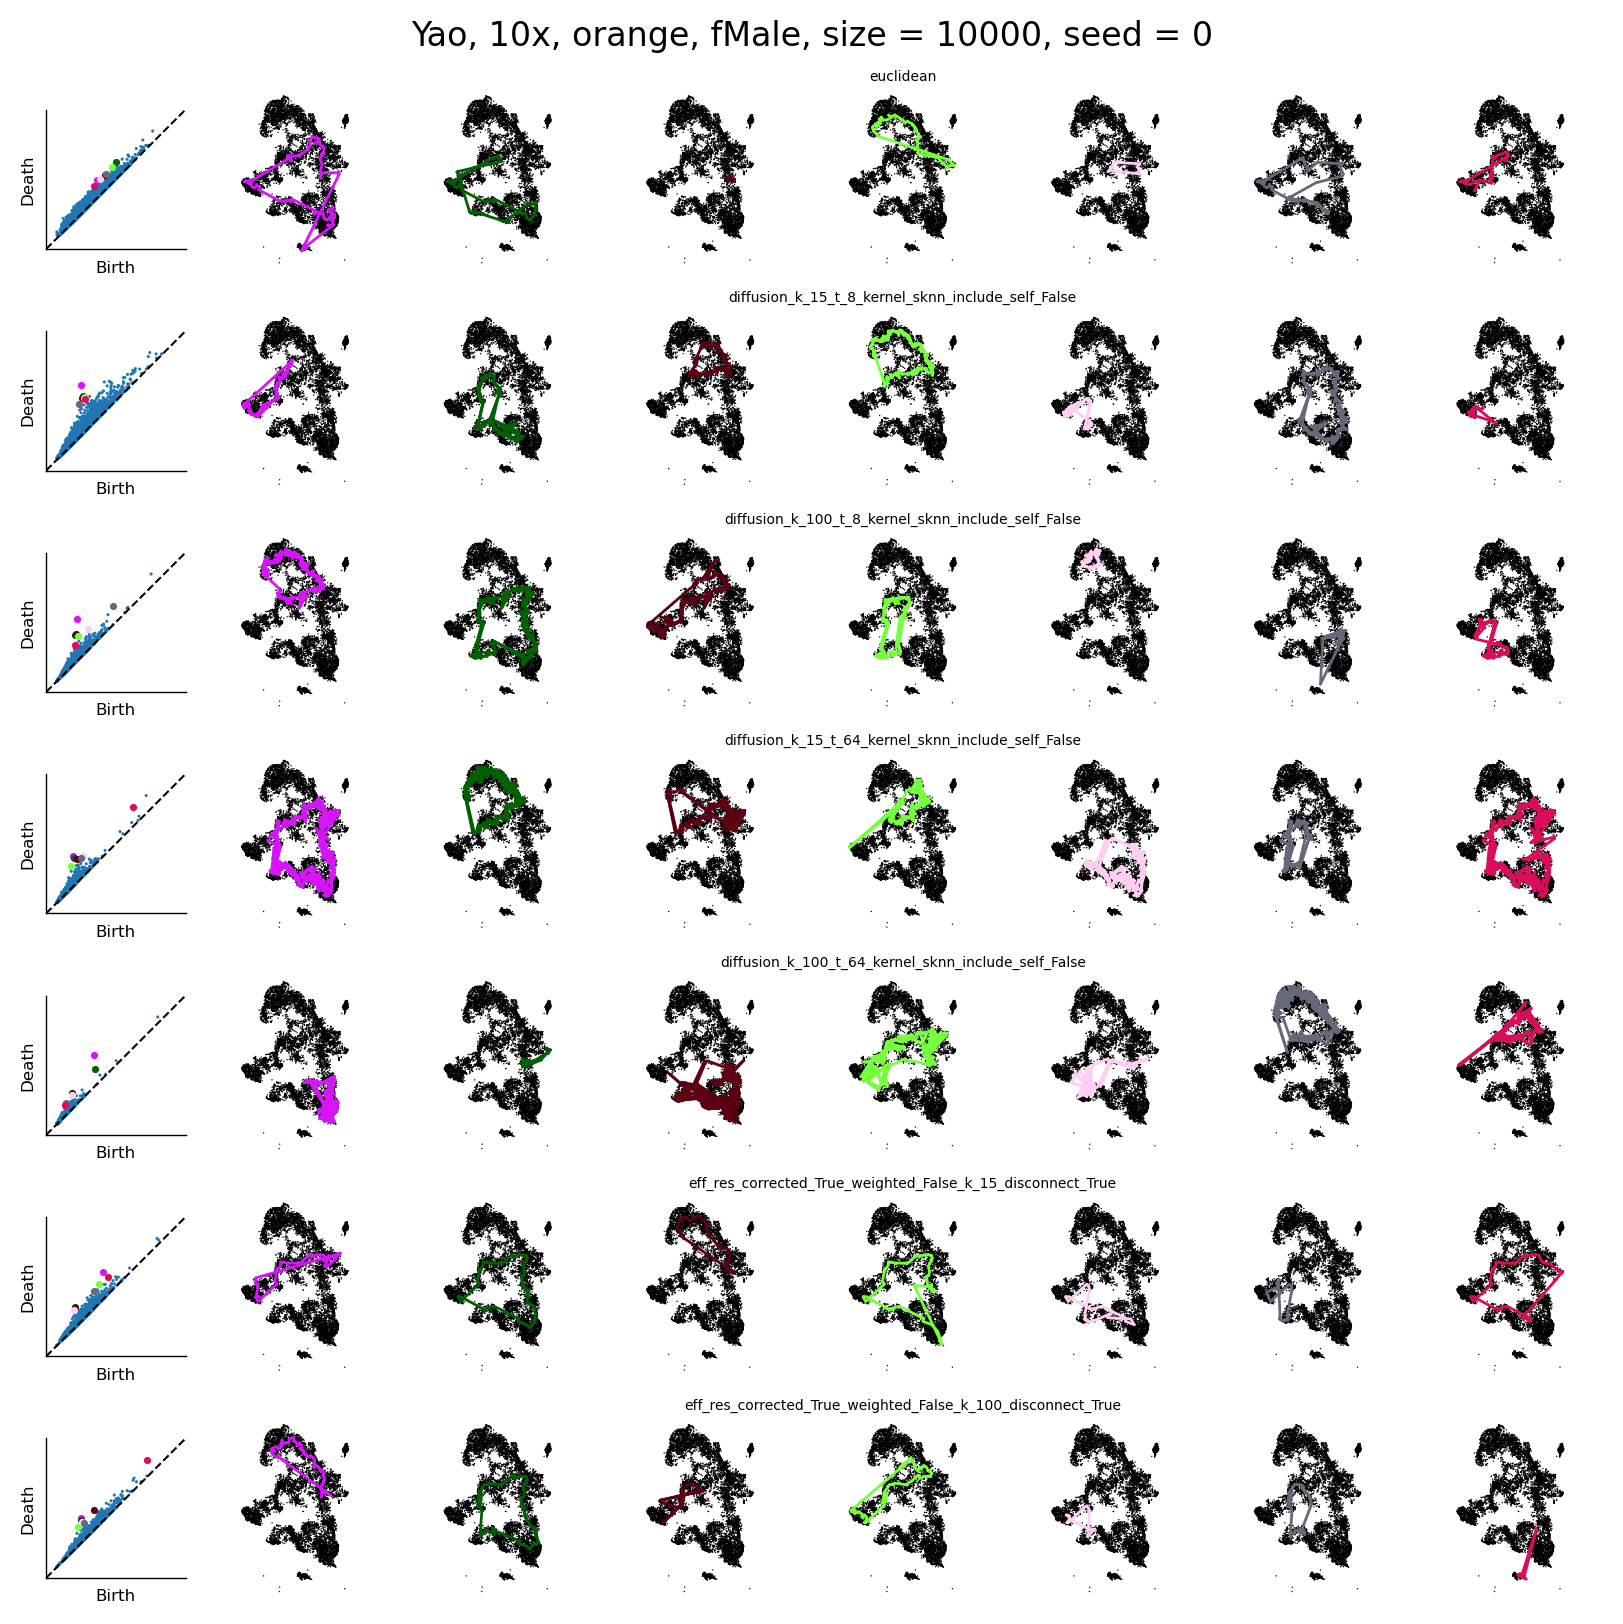

In [ ]:

n_exp = sum([len(all_res[distance]) for distance in distances.keys()])
n_cols = 8
mid_col = np.floor(n_cols/2)
plot_loops = True

width_ratios = [0.75] + [1] * (n_cols-1)

fig, ax = plt.subplots(nrows=n_exp, ncols=n_cols, figsize=(8, 8), constrained_layout=True, width_ratios=width_ratios)
seed = 0
row = 0
for i, distance in enumerate(distances.keys()):
    for j, full_dist in enumerate(all_res[distance]):
        res = all_res[distance][full_dist]    #[seed]        
        if len(res["dgms"][1]) != 0:
            np.random.seed(0)
            mm_o = np.random.choice(len(idx_mask_orange), 10000, replace=False)
            ax[row][int(mid_col)].set_title(full_dist, fontsize=5) 
            plot_dgm_loops(res, embd[mask_orange][mm_o], y="k", n_loops=0, ax=ax[row], plot_only=[1], style=style_file, linewidth=1, plot_loops=plot_loops)
        else:
            ax[row][int(mid_col)].set_title(full_dist, fontsize=5)
            revised = res["dgms"]
            # revised[1] = np.array([[0,0],[1,1]])
            revised[1] = np.zeros((1,2))
            ax0 = ax[row][0]
            ax0.legend().set_visible(False)
            ax0.set_xticks([])
            ax0.set_yticks([])
            ax0.set_ylabel("Death")
            ax0.set_xlabel("Birth")
            plot_diagrams(revised, show=False, ax=ax0, size=0, plot_only=[1])
            for i in range(n_cols-1):
                plot_scatter(ax[row][i+1], embd, y="k", s=0.2, alpha=1, cmap="tab20", scalebar=False)
        # for s in range(n_cols-1):
        #     ax[row][s+1].set_xlim(-90, 0)
        
        ax[row][0].legend().set_visible(False)
        ax[row][0].set_xticks([])
        ax[row][0].set_yticks([])
        ax[row][0].set_ylabel("Death")
        row+=1
fig.suptitle("Yao, 10x, orange, fMale, size = 10000, seed = 0", fontsize = 12)       
plt.show()
# fig.savefig(os.path.join(get_path("figures"), f"orange_10x_0.png"), dpi=300)


# passing cells

/tmp/ipykernel_107508/3351940093.py:52: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.autofmt_xdate()
/tmp/ipykernel_107508/3351940093.py:53: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


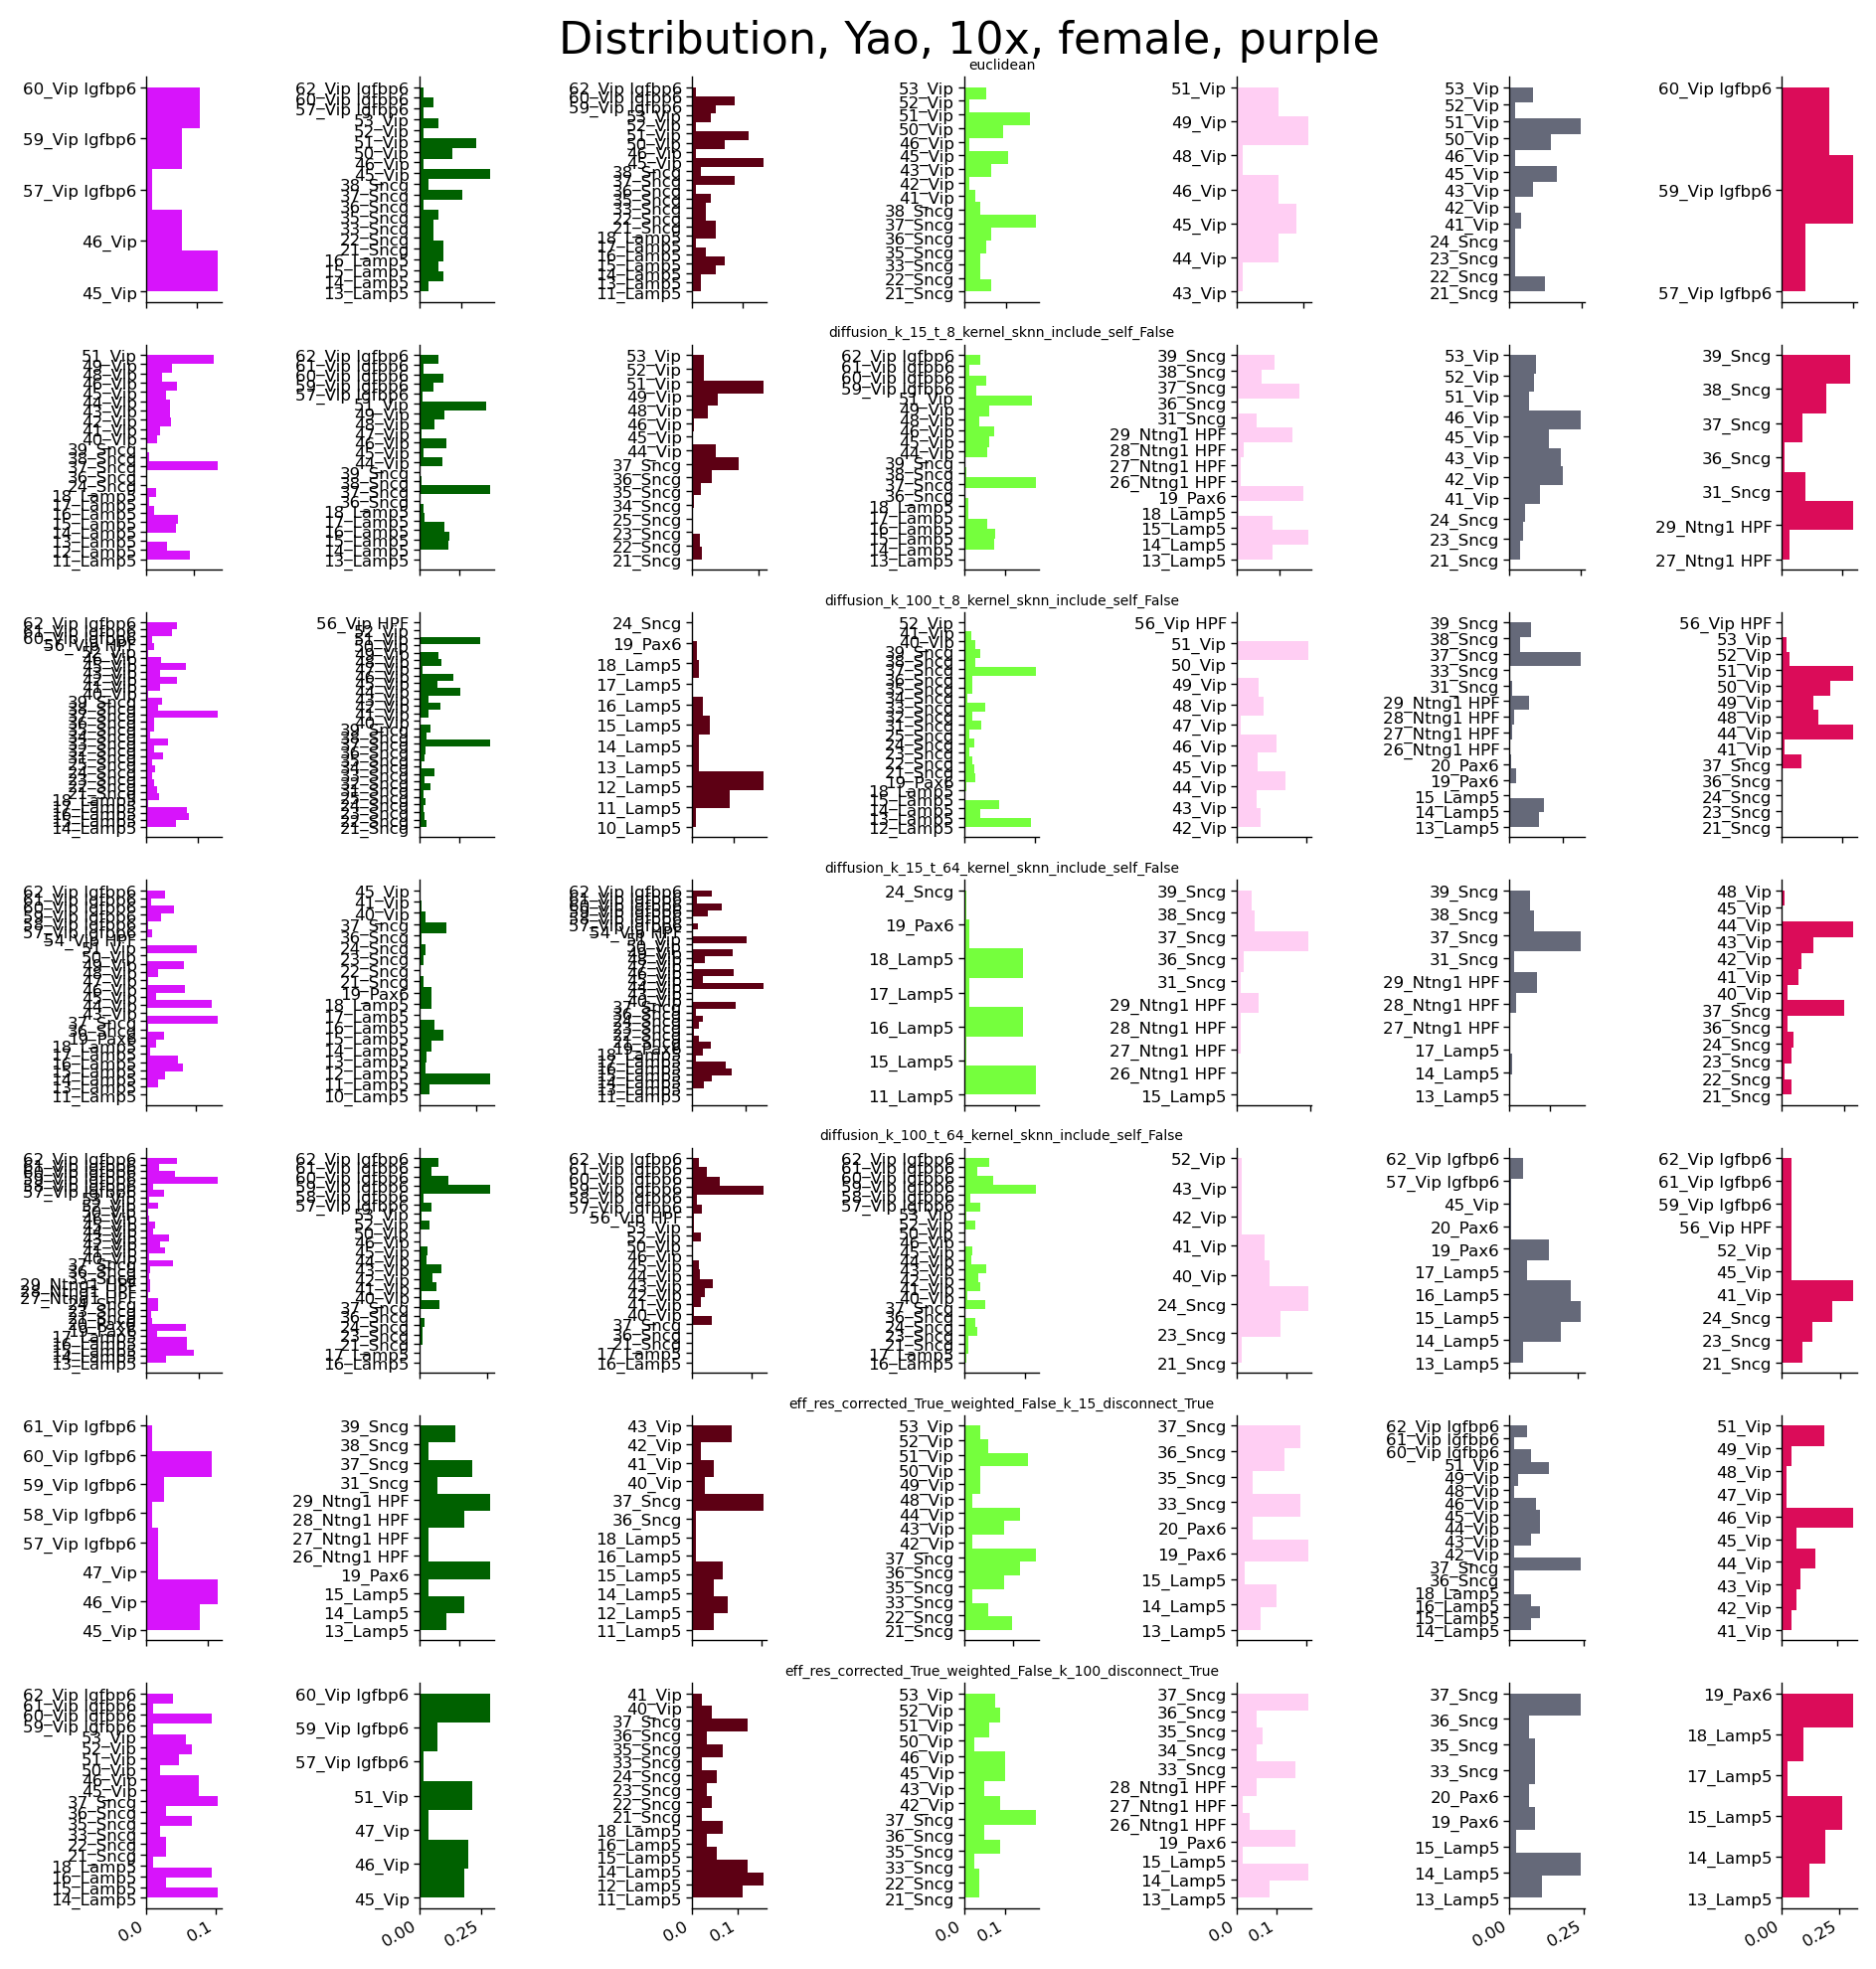

In [ ]:
n_exp = sum([len(all_res[distance]) for distance in distances.keys()])
n_cols = 7
mid_col = np.floor(n_cols/2)
plot_loops = True

# '#00d2ff', 
color_list = ['#d714fb', '#006100', '#5d0014', '#75ff3d', '#ffcef3', '#656979', '#db0c59']

width_ratios = [0.75] + [1] * (n_cols-1)

fig, ax = plt.subplots(nrows=n_exp, ncols=n_cols, constrained_layout=True, figsize=(10, 10))
#  , width_ratios=width_ratios
seed = 0
row = 0

masked_type = full_d['clusters'][mask_orange][mm_o]

orange_10x_female_dict = {"cluster_orange": cluster_orange}

for i, distance in enumerate(distances.keys()):
    for j, full_dist in enumerate(all_res[distance]):
        orange_10x_female_dict[full_dist] = []
        
        res = all_res[distance][full_dist]   
        life_times_loops = get_life_times(res, dim=1)
        loop_idx_sorted = np.argsort(life_times_loops)[::-1][:n_cols]

        # print(loop_idx_sorted)
        # print(len(res["cycles"][1]))
        
        for k in range(n_cols):
            edge = res["cycles"][1][loop_idx_sorted[k]]
            cell_type_idx = list(set(edge.flatten()))
            
            loop_type_idx = masked_type[cell_type_idx]
            loop_type_idx = sorted(loop_type_idx)
            
            cell_type = full_d['clusterNames'][loop_type_idx]
            
            # relabel_cell_type = [tasic_to_yao[tasic_type] for tasic_type in cell_type]

            density = compute_density(list(cell_type), cluster_orange)
            orange_10x_female_dict[full_dist].append(density)
            
            weights= np.ones_like(loop_type_idx) / len(loop_type_idx)
            
            ax[row][k].hist(cell_type, bins = len(set(loop_type_idx)), weights = weights, orientation='horizontal', color = color_list[k]) #color_list[k]
            ax[row][k].set_box_aspect(aspect=3)
        ax[row][3].set_title(full_dist, fontsize=5)   
        row+=1
fig.suptitle("Distribution, Yao, 10x, female, orange", fontsize = 16)
fig.autofmt_xdate()
plt.tight_layout()    
plt.show()
# fig.savefig(os.path.join(get_path("figures"), f"Distri_tasic_orange.png"), dpi=300)
save_dict(orange_10x_female_dict, os.path.join(get_path("data"), "dist_10x_female_orange.pkl"))


# total variation: female

In [483]:
dist_10x_male_orange = load_dict(os.path.join(root_path, "dist_10x_orange.pkl"))
dist_10x_female_orange = load_dict(os.path.join(root_path, "dist_10x_female_orange.pkl"))

In [485]:
full_dist = list(dist_10x_male_orange.keys())[1:]

In [488]:
ticks, reshape_10x_male_orange = reshape_dist(dist_10x_male_orange,7)
_, reshape_10x_female_orange = reshape_dist(dist_10x_female_orange,7)

In [508]:
mat = total_variation_matrix(reshape_10x_female_orange, reshape_10x_female_orange)
clusters, list_of_communities = complete_linkage(mat, threshold =0.8)
partition = turn_to_partition(list_of_communities)

In [509]:
np.random.seed(0)
mm_o = np.random.choice(len(idx_mask_orange), 10000, replace=False)
embd_orange_10x_male = embd[mask_orange][mm_o]

Done with yao_10x_female_purple_10k None euclidean n_outliers=0, perturbation=None
Done with yao_10x_female_purple_10k None diffusion_k_15_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_female_purple_10k None diffusion_k_100_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_female_purple_10k None diffusion_k_15_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_female_purple_10k None diffusion_k_100_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_female_purple_10k None eff_res_corrected_True_weighted_False_k_15_disconnect_True n_outliers=0, perturbation=None
Done with yao_10x_female_purple_10k None eff_res_corrected_True_weighted_False_k_100_disconnect_True n_outliers=0, perturbation=None


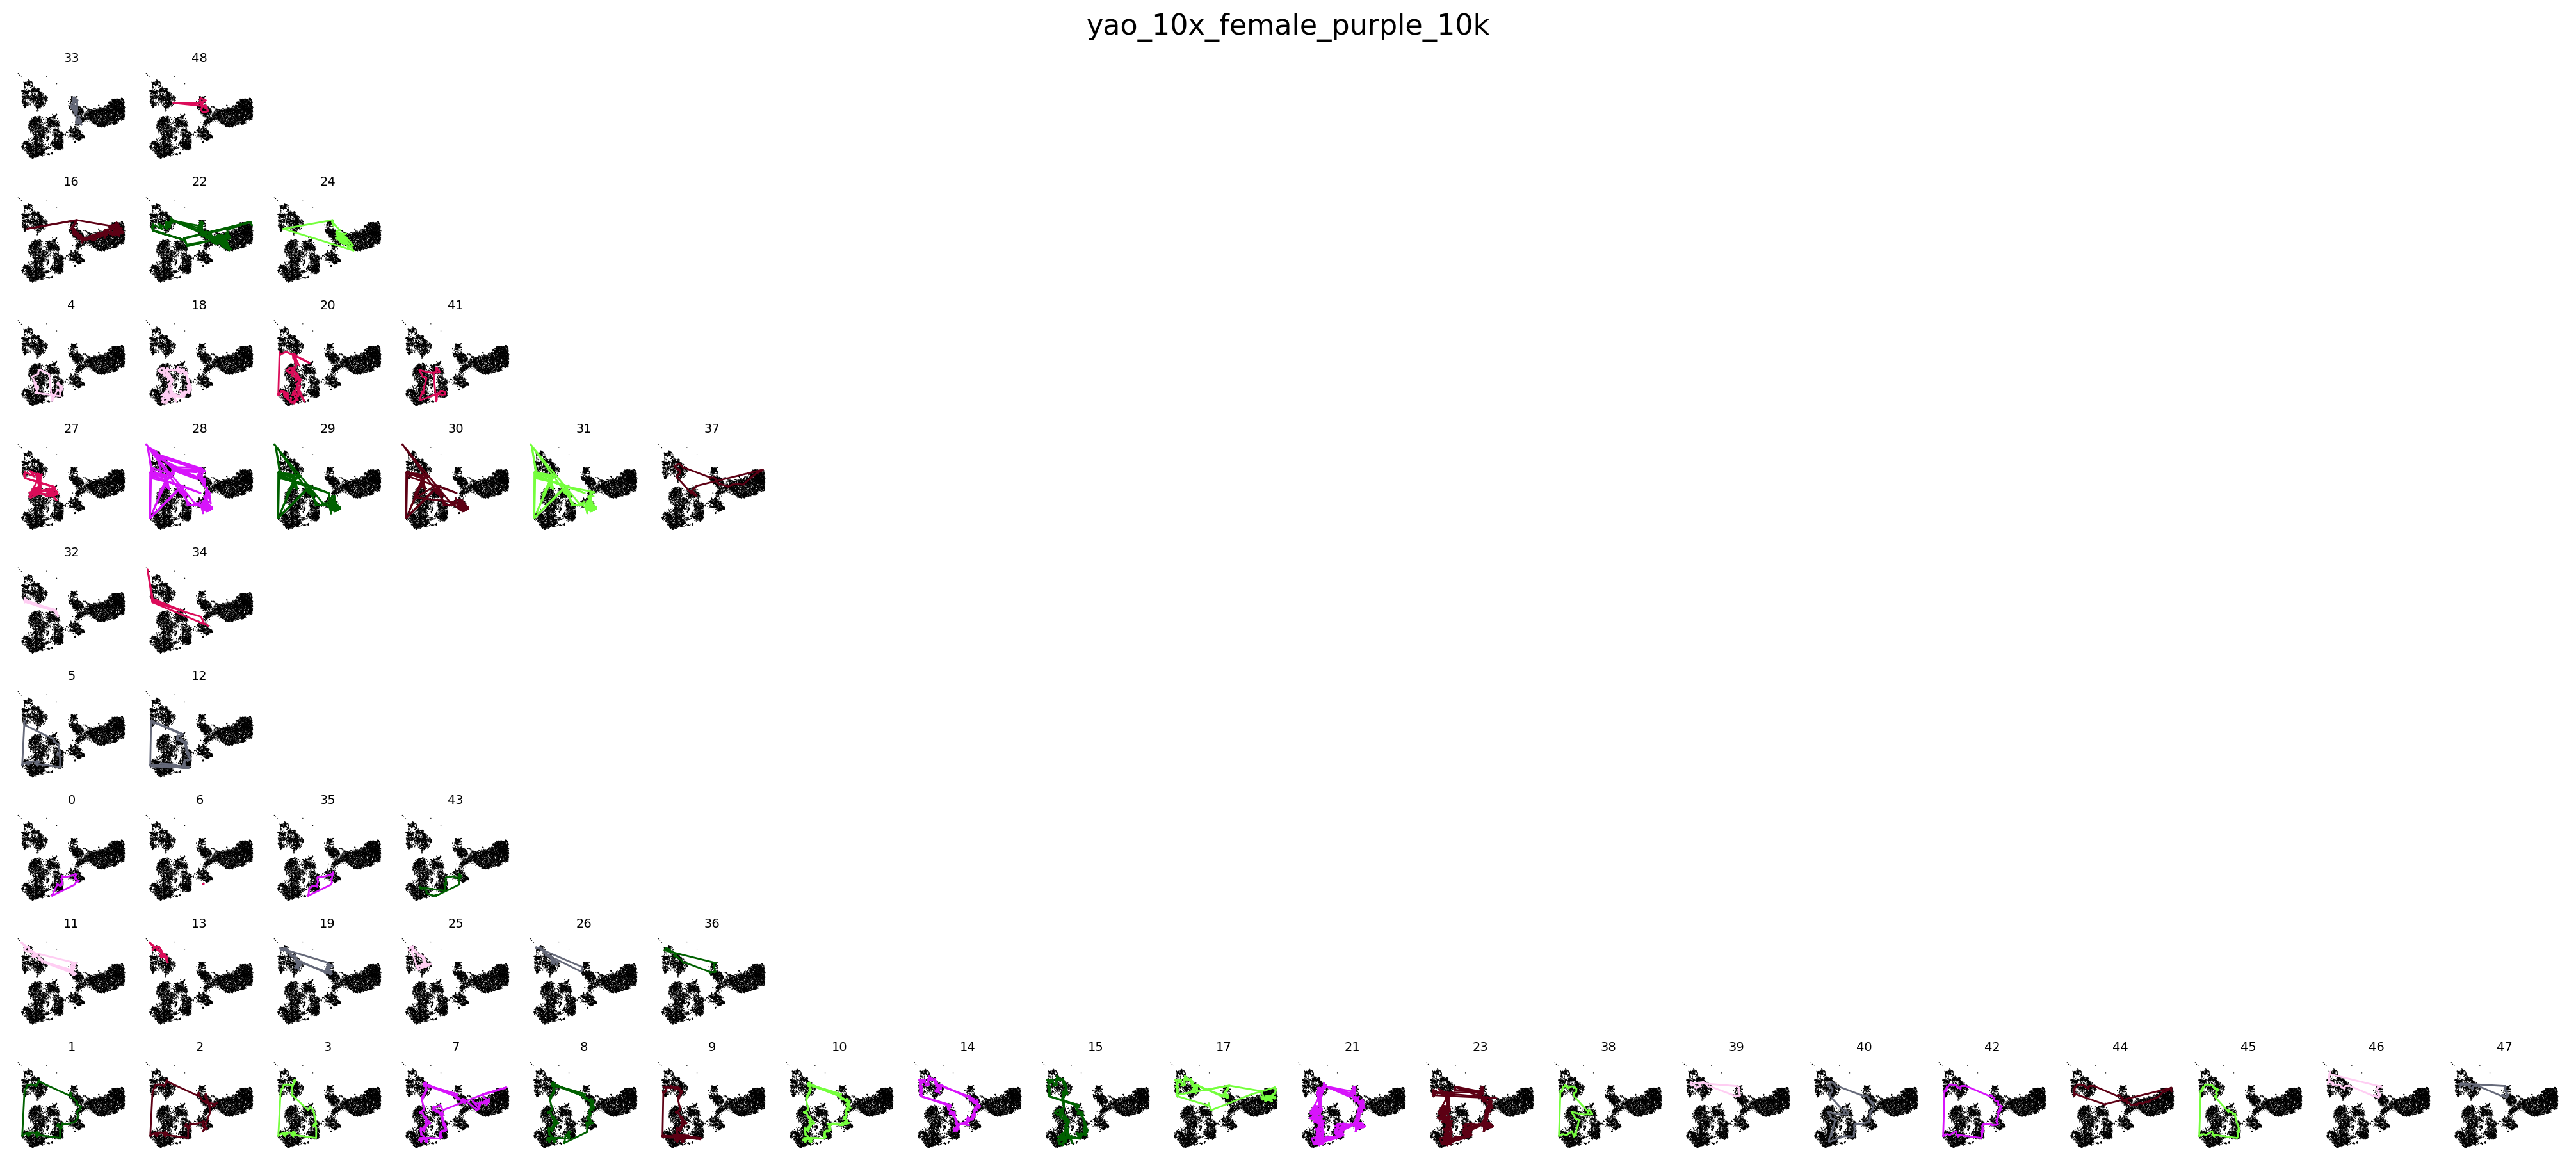

In [510]:
pic_pigeonhole_loops(partition, ticks, "yao_10x_female_orange_10k", embd_orange_10x_male, xlim = None, ylim = None)#, saveas = "pic_10x_purple.png"

## functions for total variation.....

In [496]:
def total_variation(dist_1, dist_2):
    return 0.5 * np.sum(np.abs(dist_1 - dist_2))

In [495]:
def reshape_dist(dist, num = None):
    #num: number of loops per condition
    full_dist = list(dist.keys())[1:]
    size = len(dist[list(dist.keys())[0]])
    result = np.zeros((1,size))
    ticks = []
    # shorten_dist = ['euclidean',
    #     'diffusion_k_15_t_8',
    #     'diffusion_k_100_t_8',
    #     'diffusion_k_15_t_64',
    #     'diffusion_k_100_t_64',
    #     'eff_res_k_15',
    #     'eff_res_k_100']
    shorten_dist = ['euc',
        'diff_15_8',
        'diff_100_8',
        'diff_15_64',
        'diff_100_64',
        'eff_15',
        'eff_100']
    for shorten, condition in zip(shorten_dist, full_dist):
        if num is not None:
            result = np.vstack((result, np.array(dist[condition][:int(num)])))
            ticks.extend([f"{shorten}"+f"_{i}"for i in range(num)])
        else:
            result = np.vstack((result, np.array(dist[condition])))
            ticks.extend([f"{shorten}"+f"_{i}"for i in range(7)])
    return ticks, result[1:,:]

In [507]:
def complete_linkage(mat, threshold = 0.4):
    link = linkage(squareform(mat), method='complete')
    clusters = fcluster(link, t=threshold, criterion='distance')
    
    # row_dendr = dendrogram(link)
    # print(pd.DataFrame(link, 
    #          columns=['row label 1', 'row label 2', 'distance', 'no. of items in clust.'],
    #          index=['cluster %d' %(i+1) for i in range(link.shape[0])]))
    
    list_of_communities = [[] for _ in range(max(clusters))]
    for i, cluster in enumerate(clusters):
        list_of_communities[cluster-1].append(i)
    
    return clusters, list_of_communities

In [493]:
def total_variation_matrix(reshaped_array1, reshaped_array2):
    size = reshaped_array1.shape[0]
    result = np.zeros((size, size))
    for i in range(size):
        for j in range(size):
            result[i][j] = total_variation(reshaped_array1[i,:], reshaped_array2[j,:])
    return result

In [492]:
def turn_to_partition(list_of_communities_corrected):
    manual_partition = {num: idx for idx, sublist in enumerate(list_of_communities_corrected) for num in sublist}
    manual_partition = dict(sorted(manual_partition.items()))
    return manual_partition

In [490]:
def tune_tri_threshold(lower_b = 0.5, higher_b = 1.0):
    ts = np.arange(lower_b, higher_b, 0.01)
    ave_tv = np.zeros((ts.shape))
    n_tv = np.zeros((ts.shape))
    size = 49
    
    zeros = np.zeros(mat_y_10.shape)
    tri_mat_raw = np.block([[mat_tasic, mat_t_y, mat_t_10],[zeros,mat_yao,mat_y_10],[zeros,zeros,mat_10x]])
    upper_tri = np.triu(tri_mat_raw)
    tri_mat = upper_tri + upper_tri.T
    np.fill_diagonal(tri_mat, 0)
    
    for i, t in enumerate(ts):
        partition, trim_list_of_communities = complete_linkage_tri(threshold = t)
        # print(len(trim_list_of_communities))
        tvs = []
        for l in trim_list_of_communities[:-1]:
            l_tasic = [a for a in l if a <size]
            l_yao = [b for b in l if b >=size and b < 2*size]
            l_10x = [c for c in l if c >2*size]
            # print(i)
            # print([tri_mat[a,b], tri_mat[b,c], tri_mat[a,c]] for a in l_tasic for b in l_yao for c in l_10x)
            tvs = tvs + [np.mean([tri_mat[a,b], tri_mat[b,c], tri_mat[a,c]]) for a in l_tasic for b in l_yao for c in l_10x]
        ave_tv[i] = np.mean(np.array(tvs))
        n_tv[i] = len(tvs)
    return tri_mat, ave_tv, n_tv

In [ ]:
def pic_pigeonhole_loops(partition, ticks, dataset, embd_n_mask, xlim = None, ylim = None, saveas = None):
    if type(embd_n_mask) is tuple:
        embd_n_mask = embd_n_mask[0][embd_n_mask[1]]
    rows = len(set(partition.values()))
    columns = np.max([list(partition.values()).count(value) for value in range(rows)])
    
    width_ratios = [0.75] + [1] * (columns-1)
    fig, ax = plt.subplots(rows, columns, figsize=(columns*1, rows*1), constrained_layout=True) #, width_ratios=width_ratios
    
    distances = {
        "euclidean": [{}],
            "diffusion": [
            {"k": 15, "t": 8, "kernel": "sknn", "include_self": False},
            {"k": 100, "t": 8, "kernel": "sknn", "include_self": False},
            {"k": 15, "t": 64, "kernel": "sknn", "include_self": False},
            {"k": 100, "t": 64, "kernel": "sknn", "include_self": False},
        ],
        "eff_res": [
            {"corrected": True, "weighted": False, "k": 15, "disconnect": True},
            {"corrected": True, "weighted": False, "k": 100, "disconnect": True},
        ],
    }
    root_path = get_path("data")
    all_res = load_multiple_res(datasets=dataset, n=None, embd_dims=None, sigmas=None, distances=distances, seeds=0, root_path=root_path, n_threads=1)

    # n_exp = sum([len(all_res[distance]) for distance in distances.keys()])
    # n_cols = 8
    # mid_col = np.floor(n_cols/2)
    plot_loops = True
    colors = ['#d714fb', '#006100', '#5d0014', '#75ff3d', '#ffcef3', '#656979', '#db0c59']
    idx = 0
    pos_list = [0]*rows
    for distance in distances.keys():
        for full_dist in all_res[distance]:
            res = all_res[distance][full_dist]
            life_times_loops = get_life_times(res, dim=1)
            loop_idx_sorted = np.argsort(life_times_loops)[::-1][:7]
            for n in range(7):
                row = partition[idx]
                cax = ax[row][pos_list[row]]
                cax.set_title(idx, fontsize=7)
                if ylim is not None:
                    cax.set_ylim(*ylim)
                if xlim is not None:
                    cax.set_xlim(*xlim)
                plot_scatter(cax, embd_n_mask, y="k", s=1, alpha=1, scalebar=False)
                plot_edges_on_scatter(ax=cax,
                                 edge_idx=res["cycles"][1][loop_idx_sorted[n]],
                                 x=embd_n_mask,
                                 color=colors[n],
                                 linewidth=1)
            #we assume there's loop everywhere..........a
                pos_list[row]+=1
                idx+=1
    for axx in ax.flat:
        axx.axis('off')
    fig.suptitle(dataset, fontsize = 16)       
    plt.show()
    if saveas is not None:
        fig.savefig(os.path.join(get_path("figures"), saveas), dpi=300)

# total variation: male * female: didnt start.......